# Лабораторна робота №4. Дослідження польових транзисторів

**Мета роботи:** дослідження принципу роботи та основних властивостей польового транзистора; дослідження характеристик транзистора та визначення його основних параметрів.

У цьому зошиті лабораторна робота виконується не в TINA, а шляхом SPICE-моделювання (PySpice + ngspice) — так само, як `Лб3_Біполярні_транзистори.ipynb`: схема рис. 4.6 (джерело VS1 — напруга затвор–витік, VS2 — напруга стік–витік) моделюється розгорткою по постійному струму, сімейства характеристик будуються в циклі (аналог багатоваріантного аналізу TINA), а параметри визначаються чисельно замість курсорів "a" і "b".

**У цій першій версії використовуються SPICE-моделі аналогів**, а не точні моделі транзисторів, призначених бригадам:

| Бригада | Транзистор | Тип | Модель-аналог у зошиті |
|---|---|---|---|
| 1 | IRF340 | МДН з індукованим каналом n-типу | IRF540 (International Rectifier, `models/mosfet.lib`) |
| 2 | IRF9130 | МДН з індукованим каналом p-типу | узагальнена p-МДН модель (LEVEL 1) |
| 3 | BC264C | ПТ з p-n переходом, канал n-типу | BF245B (Philips, `models/jfet.lib`) |
| 4 | 2N5460 | ПТ з p-n переходом, канал p-типу | узагальнена p-JFET модель |
| 5 | IRF630 | МДН з індукованим каналом n-типу | IRF540 (International Rectifier, `models/mosfet.lib`) |
| 6 | 2N6845 | МДН з індукованим каналом p-типу | узагальнена p-МДН модель (LEVEL 1) |

Методика від цього не змінюється: якщо буде знайдено `.model`/`.subckt` для потрібного транзистора — досить замінити опис моделі в комірці «Модель транзистора», і всі розрахунки перерахуються автоматично.

## Короткі теоретичні відомості

У польовому транзисторі (ПТ) струм стоку $I_С$ керується **електричним полем** затвора, тому струм затвора практично відсутній, а вхідний опір дуже великий. У ПТ з **керуючим p-n переходом** (JFET) зворотна напруга $U_{ЗВ}$ розширює p-n переходи і звужує канал; при $|U_{ЗВ}|=|U_{ЗВ.відс}|$ канал перекривається і $I_С\to 0$ (рис. 4.4, а). Для пологої ділянки вихідних характеристик справедливе рівняння Шоклі:

$$I_С = I_{С.поч}\left(1-\frac{U_{ЗВ}}{U_{ЗВ.відс}}\right)^2 .$$

У **МДН-транзисторі з індукованим каналом** канал утворюється лише при $|U_{ЗВ}|>|U_{пор}|$, і на пологій ділянці

$$I_С = \frac{K}{2}\left(U_{ЗВ}-U_{пор}\right)^2 .$$

Межа пологої ділянки (насичення): $U_{СВ.нас}=U_{ЗВ}-U_{ЗВ.відс}$ (для МДН — $U_{ЗВ}-U_{пор}$). Основні параметри:

$$S=\frac{\Delta I_С}{\Delta U_{ЗВ}}\Big|_{U_{СВ}=const}\ \text{(крутизна)},\qquad
g_{22}=\frac{\Delta I_С}{\Delta U_{СВ}}\Big|_{U_{ЗВ}=const},\ \ r_i=\frac{1}{g_{22}}\ \text{(вихідна провідність, внутрішній опір)},\qquad \mu = S\,r_i .$$

На **початковій (крутій) ділянці** вихідних характеристик при малих $U_{СВ}$ транзистор поводиться як резистор, керований напругою (рис. 4.5); для JFET (формула 4.1)

$$R_{СВ}=\frac{R_{СВ0}}{1-U_{ЗВ}/U_{ЗВ.відс}},$$

для МДН — $R_{СВ}=1/\left[K(U_{ЗВ}-U_{пор})\right]$. В обох випадках **опір каналу на крутій ділянці обернений до крутизни на пологій ділянці** при тій самій $U_{ЗВ}$: $R_{СВ}\approx 1/S$.

In [1]:
import warnings
warnings.filterwarnings('ignore', message='Unable to import Axes3D')   # конфлікт системного і pip-matplotlib, на роботу не впливає
import logging
logging.getLogger('PySpice').setLevel(logging.CRITICAL)   # приховує інформаційні повідомлення ngspice ("Using SPARSE...", "Unsupported Ngspice version")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact

from PySpice.Spice.Netlist import Circuit
from PySpice.Unit import *

import schemdraw
import schemdraw.elements as elm
elm.style(elm.STYLE_IEC)   # умовні позначення за ДСТУ/IEC (резистор — прямокутник)

%matplotlib inline

## Модель транзистора та схема для зняття характеристик

Оберіть номер бригади `BRIGADE`. Схема (рис. 4.6): витік заземлений, VS1 задає $U_{ЗВ}$, VS2 — $U_{СВ}$. Полярність джерел змінюється автоматично залежно від типу транзистора (`SG` — знак напруги затвора у робочому режимі, `SD` — знак напруги стоку): для n-канальних $U_{СВ}>0$, для p-канальних $U_{СВ}<0$; для JFET напруга затвора має протилежний до стоку знак, для МДН з індукованим каналом — той самий.

**Важливо (типова пастка PySpice/ngspice, див. Лб3):** постійні значення задаються звичайними числами у вольтах і амперах, без символів одиниць виміру.

In [2]:
BRIGADE = 3   # <-- номер вашої бригади (1..6)

#          транзистор  тип     опис
BRIGADES = {
    1: ('IRF340',  'nmos', 'МДН з індукованим каналом n-типу'),
    2: ('IRF9130', 'pmos', 'МДН з індукованим каналом p-типу'),
    3: ('BC264C',  'njf',  'ПТ з p-n переходом і каналом n-типу'),
    4: ('2N5460',  'pjf',  'ПТ з p-n переходом і каналом p-типу'),
    5: ('IRF630',  'nmos', 'МДН з індукованим каналом n-типу'),
    6: ('2N6845',  'pmos', 'МДН з індукованим каналом p-типу'),
}
FET_NAME, KIND, FET_DESCR = BRIGADES[BRIGADE]
SD = +1 if KIND in ('nmos', 'njf') else -1          # знак напруги стоку
SG = +1 if KIND in ('nmos', 'pjf') else -1          # знак робочої напруги затвора
IS_JFET = KIND in ('njf', 'pjf')
print(f'Бригада {BRIGADE}: {FET_NAME} — {FET_DESCR}')

Бригада 3: BC264C — ПТ з p-n переходом і каналом n-типу


In [3]:
def add_fet(circuit, drain, gate, source):
    """Модель-аналог транзистора бригади."""
    if KIND == 'nmos':      # IRF540 (Symmetry), підсхема: вузли D G S
        circuit.include('models/mosfet.lib')
        circuit.X(1, 'irf540_IR', drain, gate, source)
    elif KIND == 'pmos':    # узагальнений потужний p-МДН: Uпор = -3,2 В, Rсв.відкр ~ 0,3 Ом при Uзв = -10 В
        circuit.model('PMOS_GEN', 'PMOS', LEVEL=1, VTO=-3.2, KP=0.5, LAMBDA=0.003, RS=0.02, RD=0.03)
        circuit.MOSFET(1, drain, gate, source, source, model='PMOS_GEN')
    elif KIND == 'njf':     # BF245B (Philips)
        circuit.include('models/jfet.lib')
        circuit.JFET(1, drain, gate, source, model='BF245B')
    else:                   # узагальнений малопотужний p-JFET: Uзв.відс = +2,5 В, Iс.поч ~ 3 мА
        circuit.model('PJF_GEN', 'PJF', VTO=-2.5, BETA=0.5e-3, LAMBDA=0.01, RD=50, RS=50, IS=1e-14)
        circuit.JFET(1, drain, gate, source, model='PJF_GEN')


# послідовні опори об'ємних областей витоку і стоку (RS + RD) у моделях-аналогах, Ом
R_SERIES = {'nmos': 0.0317085 + 0.0135649, 'pmos': 0.02 + 0.03, 'njf': 184 + 258, 'pjf': 50 + 50}[KIND]


def make_circuit():
    """Рис. 4.6: витік заземлений, VS1 — затвор, VS2 — стік."""
    circuit = Circuit('FET characterization')
    vs1 = circuit.V('S1', 'gate', circuit.gnd, 0)
    vs2 = circuit.V('S2', 'drain', circuit.gnd, 0)
    add_fet(circuit, 'drain', 'gate', circuit.gnd)
    return circuit, vs1, vs2


def transfer_characteristics(vds_values, vgs_start, vgs_stop, n_points=1000):
    """Сімейство Iс = f(Uзв) для декількох Uсв (п. 4.3.1-2: VS1 — розгортка, VS2 — параметр)."""
    circuit, vs1, vs2 = make_circuit()
    curves = {}
    for vds in vds_values:
        vs2.dc_value = vds
        analysis = circuit.simulator(temperature=25, nominal_temperature=25).dc(
            VS1=slice(vgs_start, vgs_stop, (vgs_stop - vgs_start) / n_points))
        curves[vds] = (np.array(analysis.sweep), -np.array(analysis.VS2))
    return curves


def output_characteristics(vgs_values, vds_start, vds_stop, n_points=1000):
    """Сімейство Iс = f(Uсв) для декількох Uзв (п. 4.3.3-4: VS2 — розгортка, VS1 — параметр)."""
    circuit, vs1, vs2 = make_circuit()
    curves = {}
    for vgs in vgs_values:
        vs1.dc_value = vgs
        analysis = circuit.simulator(temperature=25, nominal_temperature=25).dc(
            VS2=slice(vds_start, vds_stop, (vds_stop - vds_start) / n_points))
        curves[vgs] = (np.array(analysis.sweep), -np.array(analysis.VS2))
    return curves

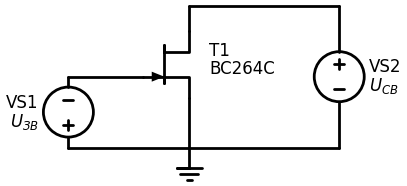

In [4]:
# Схема для дослідження польового транзистора (рис. 4.6)
# (у schemdraw стрілка затвора JFET при дзеркальному відображенні змінює напрямок, тому для n-каналу
#  використовується символ JFetP і навпаки — так стрілка n-канального ПТ спрямована ДО каналу, як за ДСТУ)
SYMBOL = {'nmos': (elm.NFet, False), 'pmos': (elm.PFet, True), 'njf': (elm.JFetP, False), 'pjf': (elm.JFetN, False)}
with schemdraw.Drawing() as d:
    d.config(fontsize=12, unit=3)
    E, flip = SYMBOL[KIND]
    T = E().right().reverse()
    if flip:
        T.flip()
    elm.Label().at((T.drain[0] + 0.3, T.center[1])).label(f'T1\n{FET_NAME}', halign='left')
    elm.Line().at(T.source).down(1)
    G = elm.Ground()
    elm.Line().at(T.gate).left(1.5)
    vs1 = elm.SourceV().down().toy(G.start).label('VS1\n$U_{ЗВ}$')
    if SG > 0:       # «+» джерела — до затвора
        vs1.reverse()
    elm.Line().right().tox(G.start)
    elm.Line().at(T.drain).up(0.5)
    elm.Line().right(3)
    vs2 = elm.SourceV().down().toy(G.start).label('VS2\n$U_{СВ}$', loc='bottom')
    if SD > 0:       # «+» джерела — до стоку
        vs2.reverse()
    elm.Line().left().tox(G.start)

## 4.3 Проведення дослідження

### 4.3.1-4.3.2 Характеристики передачі $I_С=f(U_{ЗВ})$

Параметр сімейства — $U_{СВ}$ (VS2) з кроком 10 В до 30 В (значення $U_{СВ}=0$ з методички не використовується — при ньому $I_С\equiv 0$). Діапазон розгортки $U_{ЗВ}$ (VS1) визначається типом транзистора: для JFET — від 0 до напруги відсічки, для МДН — від 0 до напруги, при якій струм стоку досягає максимального робочого значення `ID_MAX`.

Iс.поч = 8.57 мА,  Uзв.відс ~= -3.19 В  (Iс < 1 мкА при Uсв = 10 В)


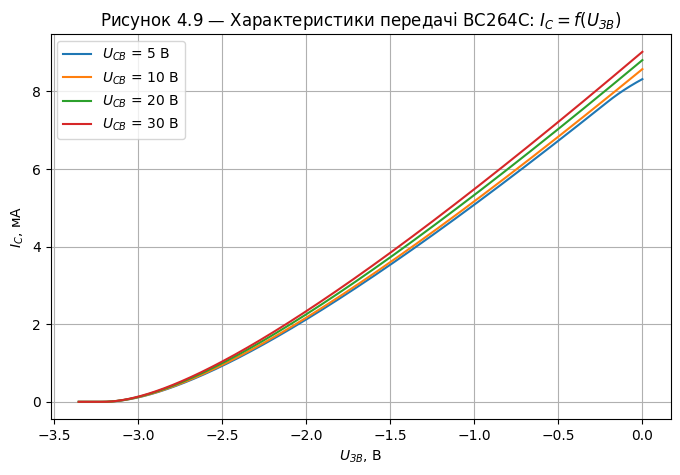

In [5]:
VDS_FAMILY = [SD * v for v in (5, 10, 20, 30)]      # В — параметр сімейства
ID_MAX = 10.0                                      # А — орієнтовний максимальний струм стоку МДН (уточніть за документацією)

# Попередня розгортка: визначаємо напругу відсічки / порогову напругу та напругу затвора, що дає ID_MAX
_vgs, _id = transfer_characteristics([SD * 10], 0, SG * (8 if IS_JFET else 12), n_points=2400)[SD * 10]
_id = np.abs(_id)
if IS_JFET:
    I_C_START = _id[0]                                         # Iс.поч (Uзв = 0)
    V_CUTOFF = _vgs[np.argmax(_id < 1e-6)]                     # Uзв.відс: Iс < 1 мкА
    VGS_END = V_CUTOFF
    print(f'Iс.поч = {I_C_START*1e3:.2f} мА,  Uзв.відс ~= {V_CUTOFF:.2f} В  (Iс < 1 мкА при Uсв = {SD*10} В)')
else:
    V_TH = _vgs[np.argmax(_id > 250e-6)]                       # Uпор: Iс = 250 мкА (як у документації)
    VGS_END = _vgs[np.argmax(_id > ID_MAX)] if _id.max() > ID_MAX else _vgs[-1]
    print(f'Uпор ~= {V_TH:.2f} В  (Iс = 250 мкА при Uсв = {SD*10} В);  Iс = {ID_MAX:g} А при Uзв ~= {VGS_END:.2f} В')

vgs_stop = VGS_END * 1.05
tr = transfer_characteristics(VDS_FAMILY, 0, vgs_stop)

plt.figure(figsize=(8, 5))
for vds, (vgs, ic) in tr.items():
    plt.plot(vgs, ic * (1e3 if IS_JFET else 1), label=f'$U_{{СВ}}$ = {vds} В')
plt.xlabel('$U_{ЗВ}$, В')
plt.ylabel('$I_С$, ' + ('мА' if IS_JFET else 'А'))
plt.title(f'Рисунок 4.9 — Характеристики передачі {FET_NAME}: $I_С=f(U_{{ЗВ}})$')
plt.legend()
plt.grid(True)
plt.show()

### 4.3.3-4.3.4 Вихідні характеристики $I_С=f(U_{СВ})$

Параметр сімейства — $U_{ЗВ}$ (VS1), 6 значень: для МДН — від порогової напруги до напруги, при якій протікає максимальний струм стоку (як рекомендує методичка), для JFET — від 0 (максимальний струм $I_{С.поч}$) до 80 % напруги відсічки.

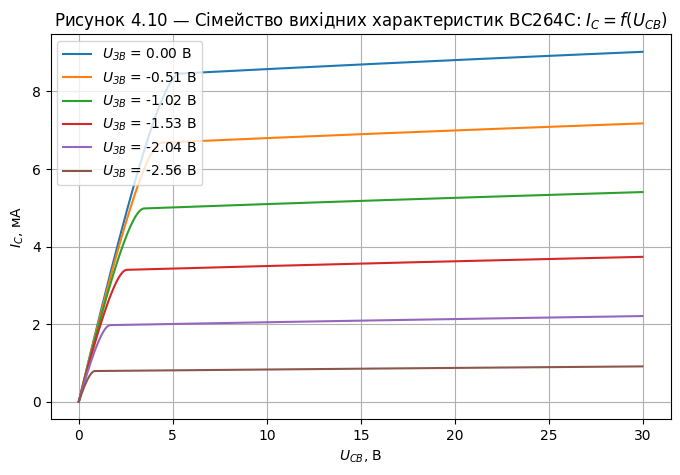

In [6]:
if IS_JFET:
    vgs_family = np.round(np.linspace(0, 0.8 * V_CUTOFF, 6), 3)
else:
    vgs_family = np.round(np.linspace(V_TH + SG * 0.1, VGS_END, 6), 3)
out = output_characteristics(vgs_family, 0, SD * 30)

UNIT, K_I = ('мА', 1e3) if IS_JFET else ('А', 1)
plt.figure(figsize=(8, 5))
for vgs, (vds, ic) in out.items():
    plt.plot(vds, ic * K_I, label=f'$U_{{ЗВ}}$ = {vgs:.2f} В')
plt.xlabel('$U_{СВ}$, В')
plt.ylabel(f'$I_С$, {UNIT}')
plt.title(f'Рисунок 4.10 — Сімейство вихідних характеристик {FET_NAME}: $I_С=f(U_{{СВ}})$')
plt.legend()
plt.grid(True)
plt.show()

## 4.4 Обробка результатів

Замість переміщення курсорів "a"/"b" мишею значення похідних визначаються чисельно (ті самі функції, що й у Лб3):

* **вздовж однієї кривої** (`local_slope`) — центральна різниця в двох сусідніх точках густої розгортки;
* **між двома сусідніми кривими сімейства** (`cross_family_slope`) — різниця значень, інтерпольованих в одній точці, поділена на крок параметра.

**Вибір кривої (п. 4.4.1):** перший студент бригади використовує вихідну характеристику з максимальним струмом, другий — із середнім, третій — з мінімальним (відмінним від нуля). Робоча точка на пологій ділянці — $U_{СВ0}$.

In [7]:
def local_slope(x, y, x0):
    """dy/dx поблизу x0 — метод двох курсорів на одній кривій."""
    x, y = np.asarray(x), np.asarray(y)
    idx = int(np.argmin(np.abs(x - x0)))
    i0, i1 = max(idx - 1, 0), min(idx + 1, len(x) - 1)
    return (y[i1] - y[i0]) / (x[i1] - x[i0]), x[idx], y[idx]


def cross_family_slope(curves, param0, x_at):
    """dy/d(параметр) при фіксованому x_at - курсори на двох НАЙБЛИЖЧИХ до param0 кривих сімейства."""
    params = np.array(sorted(curves.keys()))
    nearest_two = np.sort(np.argsort(np.abs(params - param0))[:2])
    p0, p1 = params[nearest_two[0]], params[nearest_two[1]]
    y0 = np.interp(x_at, *sorted_xy(curves[p0]))
    y1 = np.interp(x_at, *sorted_xy(curves[p1]))
    return (y1 - y0) / (p1 - p0), p0, p1, y0, y1


def sorted_xy(curve):
    """np.interp потребує зростаючого x (для p-канальних розгортка йде у від'ємний бік)."""
    x, y = curve
    order = np.argsort(x)
    return np.asarray(x)[order], np.asarray(y)[order]


def channel_resistance(vgs, dv=0.05):
    """Опір каналу на початковій ділянці: розгортка Uсв = -dv..+dv біля нуля, R = dU/dI при Uсв = 0."""
    vds, ic = output_characteristics([vgs], -dv, dv, n_points=40)[vgs]
    slope, *_ = local_slope(vds, ic, 0.0)
    return 1 / slope

In [8]:
STUDENT = 2     # <-- 1 — максимальний струм, 2 — середній, 3 — мінімальний (відмінний від нуля)
VDS0 = SD * 15  # В — робоча точка на пологій ділянці

order = sorted(vgs_family, key=lambda v: abs(out[v][1][-1]))     # від мінімального струму до максимального
Vgs0 = {1: order[-1], 2: order[len(order) // 2], 3: order[0]}[STUDENT]

# крутизна S: (а) вздовж характеристики передачі при найближчій Uсв; (б) між сусідніми вихідними кривими
vds_key = min(tr.keys(), key=lambda v: abs(v - VDS0))
S_tr, vgs_a, ic_a = local_slope(*tr[vds_key], Vgs0)
S_out, vgs_lo, vgs_hi, ic_lo, ic_hi = cross_family_slope(out, Vgs0, VDS0)
# вихідна провідність на пологій ділянці та внутрішній опір
g22, vds_a, ic_q = local_slope(*out[Vgs0], VDS0)
r_i = 1 / g22
mu = S_tr * r_i
# опір каналу у відкритому стані на початковій ділянці
R_on = channel_resistance(Vgs0)

print(f'Обрана крива: Uзв = {Vgs0:.2f} В,  робоча точка Uсв0 = {VDS0} В,  Iс0 = {ic_q*K_I:.3f} {UNIT}')
S_UNIT, K_S = ('мА/В', 1e3) if IS_JFET else ('А/В', 1)
print(f'S (характеристика передачі, Uсв = {vds_key} В)  = {S_tr*K_S:10.3f} {S_UNIT}')
print(f'S (між кривими {vgs_lo:.2f} і {vgs_hi:.2f} В)          = {S_out*K_S:10.3f} {S_UNIT}')
print(f'g22 = {g22*1e6:10.3f} мкСм,   r_i = 1/g22 = {r_i/1e3:10.3f} кОм,   μ = S·r_i = {mu:.1f}')
print(f'Rсв.відкр (початкова ділянка) = {R_on:.4g} Ом,   1/S = {1/S_tr:.4g} Ом')

Обрана крива: Uзв = -1.02 В,  робоча точка Uсв0 = 15 В,  Iс0 = 5.178 мА
S (характеристика передачі, Uсв = 10 В)  =      3.236 мА/В
S (між кривими -1.53 і -1.02 В)          =      3.163 мА/В
g22 =     16.102 мкСм,   r_i = 1/g22 =     62.106 кОм,   μ = S·r_i = 201.0
Rсв.відкр (початкова ділянка) = 516.9 Ом,   1/S = 309 Ом


### Довідкові параметри

Занесіть сюди параметри транзистора вашої бригади з документації (datasheet). Якщо значення невідомі — залиште `None`, відповідний рядок таблиці залишиться порожнім.

In [9]:
# TODO: підставте довідкові параметри для СВОГО транзистора
S_ref = None          # А/В   — крутизна (gfs, forward transconductance)
g22_ref = None        # См    — вихідна провідність (gos), для JFET
R_on_ref = None       # Ом    — опір каналу у відкритому стані (RDS(on))
V_th_ref = None       # В     — порогова напруга VGS(th) (МДН) або напруга відсічки VGS(off) (JFET)

### Таблиця 4.1 — Розраховані та довідникові значення параметрів транзистора

In [10]:
v_char = V_CUTOFF if IS_JFET else V_TH
table_4_1 = pd.DataFrame({
    'Розрахункове значення': [S_tr, g22, r_i, mu, R_on, v_char],
    'Довідкове значення': [S_ref, g22_ref, (1 / g22_ref if g22_ref else None), None, R_on_ref, V_th_ref],
}, index=['S, А/В', 'g22, См', 'r_i, Ом', 'μ', 'Rсв.відкр, Ом', 'Uзв.відс, В' if IS_JFET else 'Uпор, В'])
table_4_1

,Розрахункове значення,Довідкове значення
"S, А/В",0.003236,None
"g22, См",0.000016,None
"r_i, Ом",62105.947102,None
μ,200.988379,None
"Rсв.відкр, Ом",516.924102,None
"Uзв.відс, В",-3.193333,None


## Графіки з позначенням робочих точок ("курсорів")

Аналог рис. 4.9/4.10 з включеними курсорами "a", "b" — показують, за якими точками визначені параметри (п. 4.4.2).

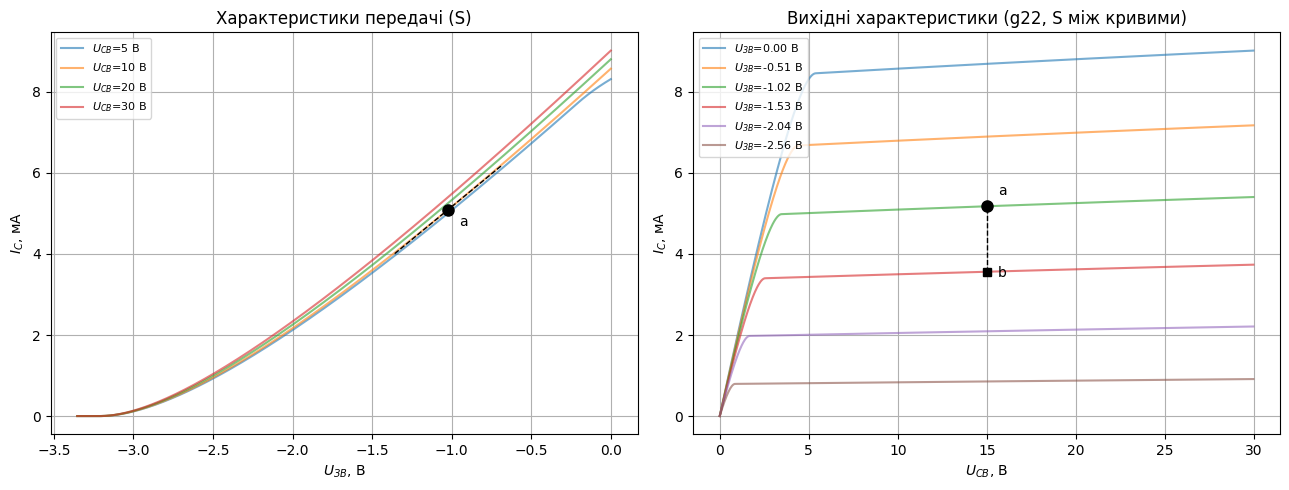

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
for vds, (vgs, ic) in tr.items():
    ax.plot(vgs, ic * K_I, alpha=0.6, label=f'$U_{{СВ}}$={vds} В')
ax.plot(vgs_a, ic_a * K_I, 'ko', ms=8)
ax.annotate('a', (vgs_a, ic_a * K_I), textcoords='offset points', xytext=(8, -12))
dv = 0.1 * abs(vgs_stop)
ax.plot([vgs_a - dv, vgs_a + dv], [(ic_a - S_tr * dv) * K_I, (ic_a + S_tr * dv) * K_I], 'k--', lw=1)
ax.set_xlabel('$U_{ЗВ}$, В'); ax.set_ylabel(f'$I_С$, {UNIT}')
ax.set_title('Характеристики передачі (S)'); ax.legend(fontsize=8); ax.grid(True)

ax = axes[1]
for vgs, (vds, ic) in out.items():
    ax.plot(vds, ic * K_I, alpha=0.6, label=f'$U_{{ЗВ}}$={vgs:.2f} В')
ax.plot(VDS0, ic_q * K_I, 'ko', ms=8)
ax.annotate('a', (VDS0, ic_q * K_I), textcoords='offset points', xytext=(8, 8))
ax.plot([VDS0, VDS0], [ic_lo * K_I, ic_hi * K_I], 'k--', lw=1)
ic_b = ic_lo if abs(ic_lo - ic_q) > abs(ic_hi - ic_q) else ic_hi     # курсор "b" — на сусідній кривій
ax.plot(VDS0, ic_b * K_I, 'ks', ms=6)
ax.annotate('b', (VDS0, ic_b * K_I), textcoords='offset points', xytext=(8, -4))
ax.set_xlabel('$U_{СВ}$, В'); ax.set_ylabel(f'$I_С$, {UNIT}')
ax.set_title('Вихідні характеристики (g22, S між кривими)'); ax.legend(fontsize=8); ax.grid(True)

plt.tight_layout()
plt.show()

## Польовий транзистор як керований резистор (рис. 4.5)

При малих $U_{СВ}$ вихідні характеристики майже лінійні і продовжуються в обидва боки від нуля — ПТ можна використовувати як **резистор, керований напругою** для малих сигналів будь-якої полярності. Нижче — початкові ділянки вихідних характеристик та залежність $R_{СВ}(U_{ЗВ})$, порівняна з $1/S$ (крутизна на пологій ділянці при $U_{СВ0}$).

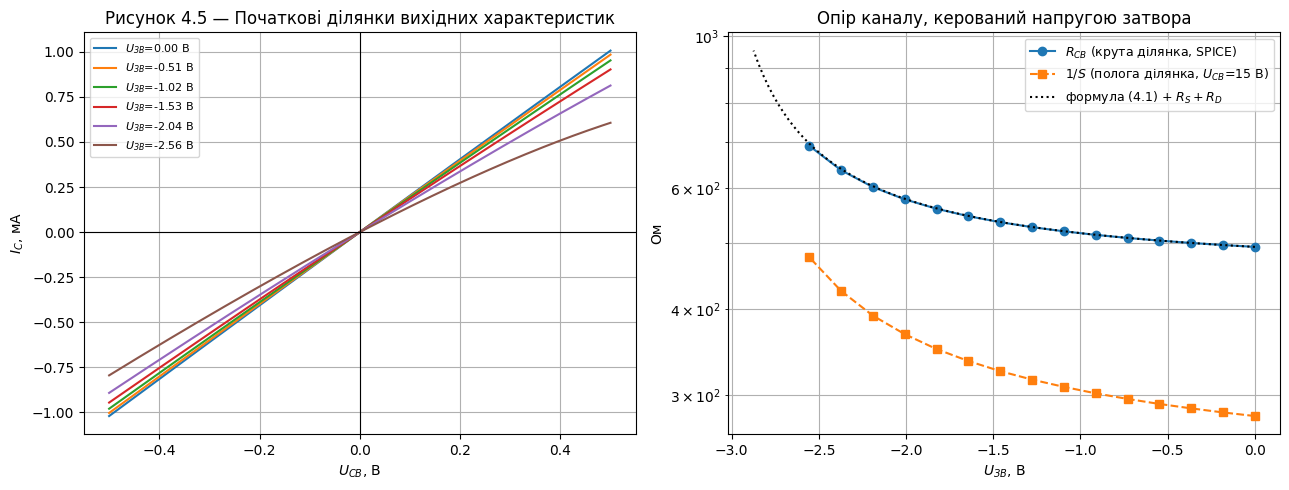

In [12]:
dv_lin = 0.5 if IS_JFET else 0.2
vcr = output_characteristics(vgs_family, -dv_lin, dv_lin, n_points=200)

vgs_scan = np.linspace(vgs_family[0], vgs_family[-1], 15)
R_scan = np.array([channel_resistance(v) for v in vgs_scan])
tr0 = transfer_characteristics([VDS0], 0, vgs_stop)[VDS0]
S_scan = np.array([local_slope(*tr0, v)[0] for v in vgs_scan])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ax = axes[0]
for vgs, (vds, ic) in vcr.items():
    ax.plot(vds, ic * K_I, label=f'$U_{{ЗВ}}$={vgs:.2f} В')
ax.axhline(0, color='k', lw=0.8); ax.axvline(0, color='k', lw=0.8)
ax.set_xlabel('$U_{СВ}$, В'); ax.set_ylabel(f'$I_С$, {UNIT}')
ax.set_title('Рисунок 4.5 — Початкові ділянки вихідних характеристик'); ax.legend(fontsize=8); ax.grid(True)

ax = axes[1]
ax.semilogy(vgs_scan, R_scan, 'o-', label='$R_{СВ}$ (крута ділянка, SPICE)')
ax.semilogy(vgs_scan, 1 / np.abs(S_scan), 's--', label=f'$1/S$ (полога ділянка, $U_{{СВ}}$={VDS0} В)')
if IS_JFET:
    R0 = channel_resistance(0.0)
    v = np.linspace(0, 0.9 * V_CUTOFF, 100)
    ax.semilogy(v, R_SERIES + (R0 - R_SERIES) / (1 - v / V_CUTOFF), 'k:', label='формула (4.1) + $R_S+R_D$')
ax.set_xlabel('$U_{ЗВ}$, В'); ax.set_ylabel('Ом')
ax.set_title('Опір каналу, керований напругою затвора'); ax.legend(fontsize=9); ax.grid(True, which='both')
plt.tight_layout()
plt.show()

Формула (4.1) описує опір лише самого каналу, тому для порівняння з моделлю до неї додано опори $R_S+R_D$. Співвідношення $R_{СВ}\approx 1/S$ виконується тим точніше, чим менші опори об'ємних областей витоку й стоку (параметри `RS`, `RD` моделі): опір каналу на крутій ділянці містить $R_S+R_D$ повністю, а крутизна зменшується лише через $R_S$ (від'ємний зворотний зв'язок, $S_{еф}=S/(1+S R_S)$). Для малопотужних JFET ці опори становлять сотні ом, тому розбіжність помітна; для потужних МДН — частки ома.

## Інтерактивний вибір робочої точки

Дозволяє кожному члену бригади швидко підставити власну криву ($U_{ЗВ}$) і робочу точку ($U_{СВ0}$) та переглянути, як змінюються параметри.

In [13]:
@interact(Vgs=widgets.FloatSlider(min=min(vgs_family), max=max(vgs_family), step=abs(vgs_family[1] - vgs_family[0]) / 4,
                                  value=Vgs0, description='$U_{ЗВ}$, В'),
          Vds=widgets.FloatSlider(min=min(SD * 2, SD * 29), max=max(SD * 2, SD * 29), step=1, value=VDS0,
                                  description='$U_{СВ0}$, В'))
def explore_operating_point(Vgs, Vds):
    vds_c, ic_c = output_characteristics([Vgs], 0, SD * 30, n_points=600)[Vgs]
    vgs_c, ic_t = transfer_characteristics([Vds], 0, vgs_stop, n_points=600)[Vds]
    s, _, _ = local_slope(vgs_c, ic_t, Vgs)
    g, _, i0 = local_slope(vds_c, ic_c, Vds)
    r_on = channel_resistance(Vgs)
    fig, ax = plt.subplots(figsize=(8, 4.5))
    for vgs, (vds, ic) in out.items():
        ax.plot(vds, ic * K_I, color='gray', alpha=0.35)
    ax.plot(vds_c, ic_c * K_I, 'r-', lw=2, label=f'$U_{{ЗВ}}$ = {Vgs:.2f} В')
    ax.plot(Vds, i0 * K_I, 'ko', ms=8)
    ax.set_xlabel('$U_{СВ}$, В'); ax.set_ylabel(f'$I_С$, {UNIT}'); ax.legend(); ax.grid(True)
    plt.show()
    print(f'Iс0 = {i0*K_I:.3f} {UNIT},  S = {s*K_S:.3f} {S_UNIT},  g22 = {g*1e6:.3f} мкСм,  '
          f'r_i = {1/g/1e3 if g else float("inf"):.2f} кОм,  Rсв.відкр = {r_on:.4g} Ом')

interactive(children=(FloatSlider(value=-1.022, description='$U_{ЗВ}$, В', max=0.0, min=-2.555, step=0.12775),…

## Висновки

*(заповнюється студентом)*

1. Навести сімейства характеристик передачі та вихідних характеристик свого транзистора з позначенням робочих точок, за якими визначались параметри.
2. Навести значення крутизни $S$, вихідної провідності $g_{22}$ (внутрішнього опору $r_i$), коефіцієнта підсилення $\mu$ та опору каналу у відкритому стані; порівняти значення $S$, отримані двома способами (вздовж характеристики передачі і між сусідніми вихідними кривими).
3. Порівняти розраховані та довідникові значення параметрів (таблиця 4.1) і пояснити розбіжності (модель-аналог, режим вимірювання в документації).
4. Пояснити, чому вихідні характеристики мають пологу ділянку (перекриття каналу біля стоку) і чому струм на ній трохи зростає ($g_{22}\neq 0$ — модуляція довжини каналу, параметр `LAMBDA` моделі).
5. Пояснити використання ПТ як резистора, керованого напругою, і зв'язок $R_{СВ}\approx 1/S$; чим обмежена точність цього співвідношення.

## Рекомендована література

1. Алехин В. А. Электротехника и электроника. Компьютерный лабораторный практикум в программной среде TINA-8. — Москва: Горячая линия — Телеком, 2014. — 208 с.
2. Руденко В. С., Сенько В. И., Трифонюк В. В. Основы промышленной электроники. — Киев: Вища школа, 1985. — 400 с.
3. Пасынков В. В., Чиркин Л. К. Полупроводниковые приборы. — Москва: Высшая школа, 1987.
4. Дулин В. Н. и др. Электронные приборы / под ред. Г. Г. Шишкина. — Москва: Энергоатомиздат, 1989.